In [2]:
import os

print(os.getcwd())
print("road.jpg" in os.listdir())

/Users/ananyaremani
True


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
image = cv2.imread("road.jpg")

if image is None:
    print("Image not found!")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (675, 1200, 3)


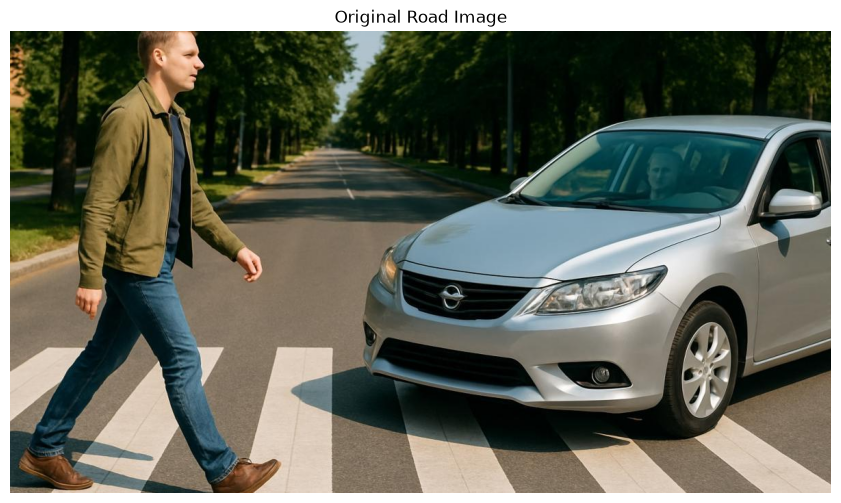

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(image_rgb)
plt.title("Original Road Image")
plt.axis("off")
plt.show()

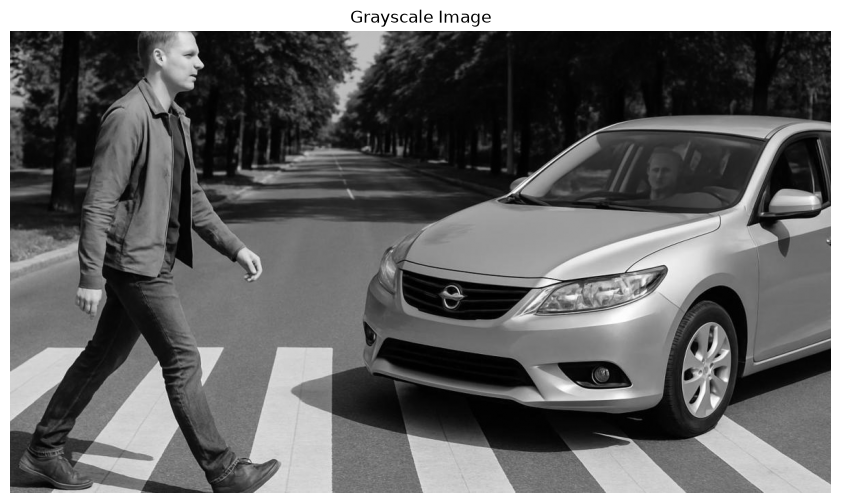

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

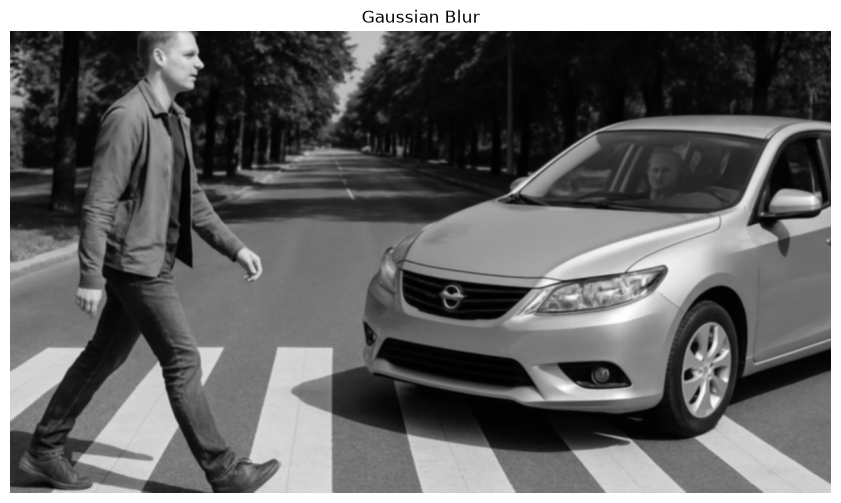

In [7]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12, 6))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

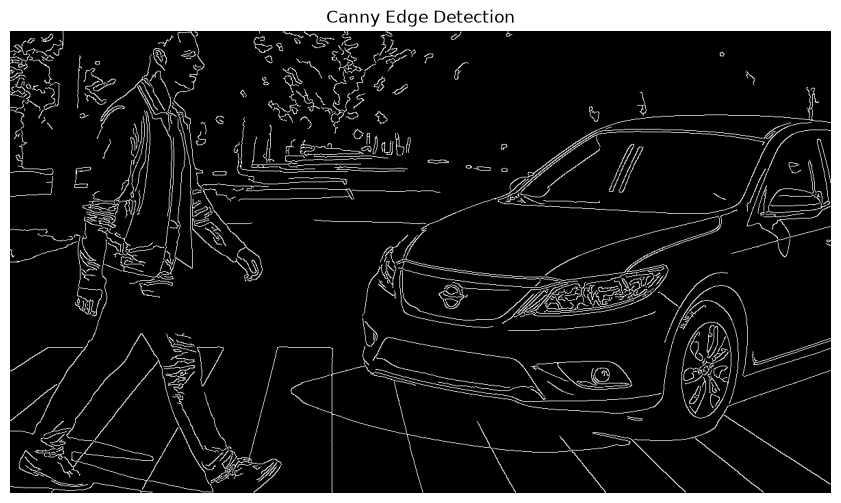

In [8]:
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(12, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

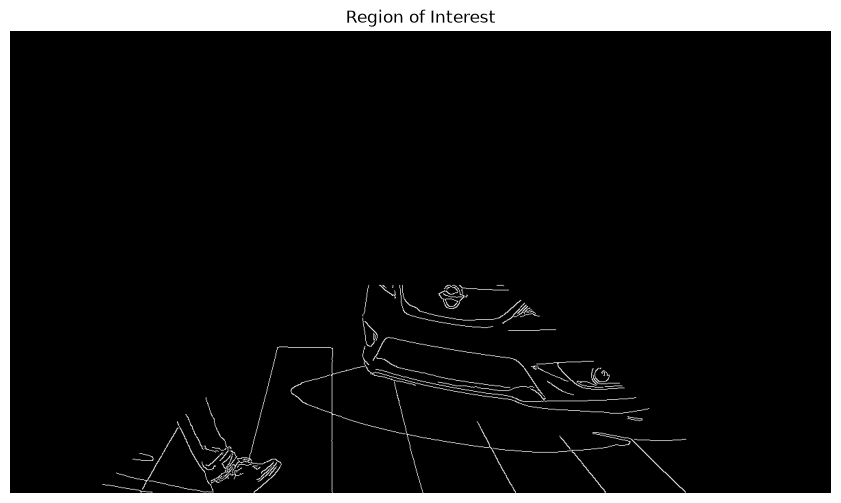

In [18]:
h, w = edges.shape

mask = np.zeros_like(edges)

polygon = np.array([[
    (int(0.10 * w), h),
    (int(0.90 * w), h),
    (int(0.60 * w), int(0.55 * h)),
    (int(0.40 * w), int(0.55 * h))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)

roi_edges = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(12, 6))
plt.imshow(roi_edges, cmap="gray")
plt.title("Region of Interest")
plt.axis("off")
plt.show()

In [11]:
lines = cv2.HoughLinesP(
    roi_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=30,
    maxLineGap=100
)

print("Hough Transform completed.")

if lines is not None:
    print("Number of lines detected:", len(lines))
else:
    print("No lines detected.")

Hough Transform completed.
Number of lines detected: 135


In [12]:
left_lines = []
right_lines = []

if lines is not None:
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        if x2 == x1:
            continue

        slope = (y2 - y1) / (x2 - x1)

        if -1.5 < slope < -0.4:
            left_lines.append((x1, y1, x2, y2))

        elif 0.4 < slope < 1.5:
            right_lines.append((x1, y1, x2, y2))

print("Left lane lines:", len(left_lines))
print("Right lane lines:", len(right_lines))

Left lane lines: 11
Right lane lines: 10


In [14]:
def average_line(lines, y_bottom, y_top):
    if len(lines) == 0:
        return None

    xs = []
    ys = []

    for x1, y1, x2, y2 in lines:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    slope, intercept = np.polyfit(xs, ys, 1)

    if abs(slope) < 1e-6:
        return None

    x_bottom = int((y_bottom - intercept) / slope)
    x_top = int((y_top - intercept) / slope)

    return x_bottom, y_bottom, x_top, y_top

In [15]:
y_bottom = h - 1
y_top = int(0.60 * h)

left_lane = average_line(left_lines, y_bottom, y_top)
right_lane = average_line(right_lines, y_bottom, y_top)

print("Left lane:", left_lane)
print("Right lane:", right_lane)

Left lane: (78, 674, 712, 405)
Right lane: (1281, 674, 363, 405)


In [16]:
output = image.copy()

if left_lane is not None:
    x1, y1, x2, y2 = left_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

if right_lane is not None:
    x1, y1, x2, y2 = right_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

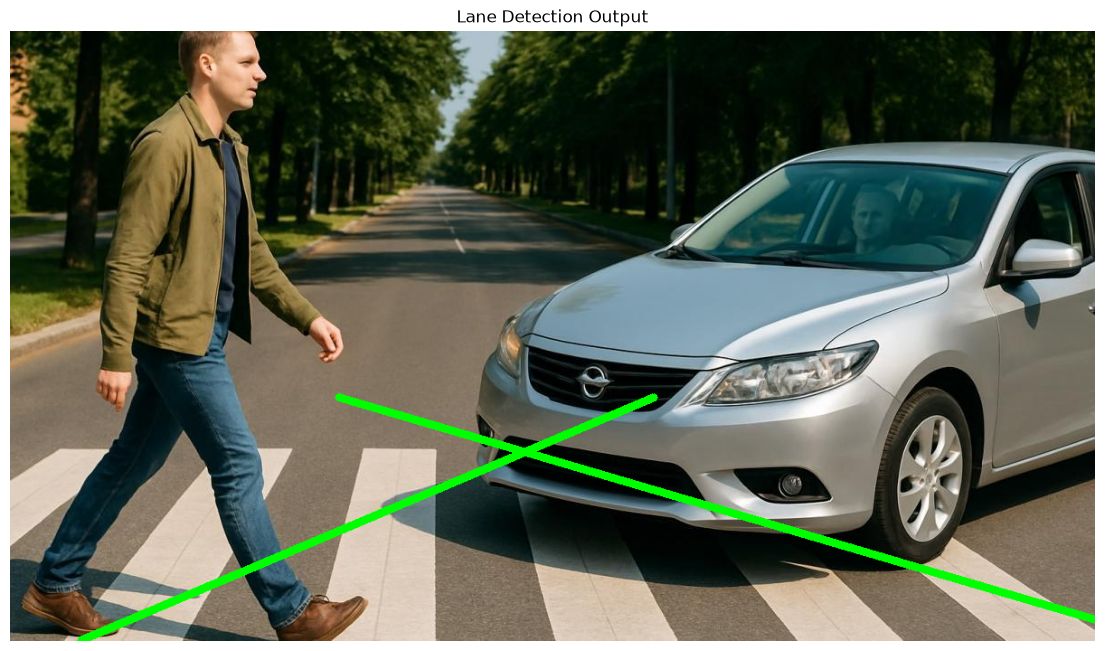

In [19]:
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title("Lane Detection Output")
plt.axis("off")
plt.show()